# Random Forest: Complete Guide

**Learning sequence:** Problem → Intuition → Ensemble Learning → Bootstrap Sampling → Random Feature Selection → Voting → From Scratch → Scikit-learn → Evaluation → OOB → Feature Importance → Tuning → Comparison → Failure Cases

This notebook develops a practical and conceptual understanding of **Random Forest** models. It focuses primarily on classification and uses the breast cancer dataset included with scikit-learn for educational modeling—not as a clinical diagnostic system.

The notebook follows the same educational philosophy as the Decision Tree notebook: first understand the idea, then the mathematics, then build small pieces from scratch, and finally use scikit-learn for a realistic workflow.


## Learning Objectives

By the end of this notebook, you should be able to:

- Explain why Random Forest is an ensemble of decision trees.
- Explain bootstrap sampling and bagging.
- Understand why Random Forest randomly samples features at tree splits.
- Explain majority voting for classification.
- Build a small educational Random Forest from scratch.
- Train a Random Forest classifier with scikit-learn.
- Evaluate a classifier with accuracy, precision, recall, F1, ROC-AUC, and a confusion matrix.
- Understand out-of-bag (OOB) evaluation.
- Interpret feature importance responsibly.
- Use permutation importance.
- Tune important Random Forest hyperparameters.
- Compare a single Decision Tree with a Random Forest.
- Recognize overfitting, leakage, class imbalance, and other common failure modes.


In [1]:
# Import the core libraries used throughout the notebook.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set a random seed so the educational examples are reproducible.
RANDOM_STATE = 42

# Make displayed tables easier to read.
pd.set_option("display.max_columns", 50)


## 1. What Is Random Forest?

A **Random Forest** is an ensemble learning method that combines many decision trees.

Instead of relying on one tree, the algorithm trains multiple trees using different bootstrap samples of the training data. At each split, a random subset of features is also considered.

For classification, the trees vote for a class and the forest combines those predictions into a final class prediction.

### Core idea

```text
Training data
      |
      +------------------+------------------+
      |                  |                  |
 Bootstrap sample 1  Bootstrap sample 2  Bootstrap sample 3 ...
      |                  |                  |
   Tree 1             Tree 2             Tree 3
      |                  |                  |
 prediction          prediction          prediction
      +------------------+------------------+
                         |
                   Majority voting
                         |
                  Final prediction
```

Random Forest therefore introduces randomness in two important places:

1. **Rows:** bootstrap samples.
2. **Features:** random feature subsets considered at splits.

This combination helps reduce the dependence on any single decision tree.


In [2]:
# Print the conceptual workflow of a Random Forest.
forest_steps = [
    ("Step 1", "Create bootstrap samples from the training data"),
    ("Step 2", "Train a decision tree on each sample"),
    ("Step 3", "Randomly consider a subset of features at each split"),
    ("Step 4", "Collect predictions from all trees"),
    ("Step 5", "Combine predictions by majority voting")
]

for step, description in forest_steps:
    print(f"{step}: {description}")


Step 1: Create bootstrap samples from the training data
Step 2: Train a decision tree on each sample
Step 3: Randomly consider a subset of features at each split
Step 4: Collect predictions from all trees
Step 5: Combine predictions by majority voting


## 2. Decision Tree vs Random Forest

A single decision tree can become very sensitive to the particular training observations it sees.

A Random Forest tries to make the overall prediction more stable by combining many trees.

### High-level comparison

| Property | Decision Tree | Random Forest |
|---|---|---|
| Basic unit | One tree | Many trees |
| Bootstrap samples | Not required | Yes, by default |
| Random feature selection | Not the defining idea | Yes |
| Interpretability | Relatively high | Lower |
| Variance | Can be high | Often reduced |
| Computation | Usually lower | Usually higher |

Random Forest does not simply mean "a very large decision tree." It is an ensemble of many separately constructed trees.


## 3. Bootstrap Sampling

Bootstrap sampling means drawing observations **with replacement**.

For a dataset containing `n` observations, one bootstrap sample usually contains `n` draws. Because sampling is with replacement, some observations may appear more than once while others may not appear in that particular sample.

Example:

```text
Original indices:
0 1 2 3 4 5

Bootstrap sample:
2 5 2 0 4 4

Repeated observations are allowed.
Some original observations may be absent.
```

The observations left out of a particular bootstrap sample are called **out-of-bag (OOB)** observations for that tree.


In [3]:
# Demonstrate bootstrap sampling on a tiny dataset.
rng = np.random.default_rng(RANDOM_STATE)

original_indices = np.arange(10)

# Sample with replacement.
bootstrap_indices = rng.choice(
    original_indices,
    size=len(original_indices),
    replace=True
)

# Observations that were not selected are out-of-bag for this sample.
oob_indices = np.setdiff1d(original_indices, np.unique(bootstrap_indices))

print("Original indices:", original_indices)
print("Bootstrap sample:", bootstrap_indices)
print("OOB indices:", oob_indices)


Original indices: [0 1 2 3 4 5 6 7 8 9]
Bootstrap sample: [0 7 6 4 4 8 0 6 2 0]
OOB indices: [1 3 5 9]


## 4. Why Does Bootstrap Sampling Help?

If every tree saw exactly the same observations and followed very similar splitting decisions, the trees could become highly correlated.

Bootstrap sampling changes the training data seen by each tree.

The forest then averages or votes across trees rather than trusting one tree.

A useful intuition is:

> Many imperfect but diverse trees can produce a more stable ensemble prediction than one highly flexible tree.

The goal is not to make every tree identical. Diversity among trees is an important part of the ensemble.


## 5. Random Feature Selection

Random Forest adds another source of randomness.

At a split, a tree does not necessarily consider every available feature. Instead, it considers a subset of features controlled by `max_features`.

This reduces the chance that the same very strong feature dominates every tree in exactly the same way.

The result is often a collection of trees that are less correlated with one another.


In [4]:
# Create a simple example showing random feature subsets.
features = np.array([
    "feature_A",
    "feature_B",
    "feature_C",
    "feature_D",
    "feature_E",
    "feature_F"
])

rng = np.random.default_rng(RANDOM_STATE)

# Consider three features at this hypothetical split.
selected_features = rng.choice(features, size=3, replace=False)

print("All features:", features.tolist())
print("Randomly selected features:", selected_features.tolist())


All features: ['feature_A', 'feature_B', 'feature_C', 'feature_D', 'feature_E', 'feature_F']
Randomly selected features: ['feature_F', 'feature_A', 'feature_D']


## 6. Majority Voting

For classification, each tree produces a class prediction.

Suppose five trees predict:

```text
Tree 1 → benign
Tree 2 → malignant
Tree 3 → benign
Tree 4 → benign
Tree 5 → benign
```

The forest prediction is:

```text
benign
```

because benign receives the majority of votes.

For binary or multiclass classification, the same basic idea extends to the class with the largest number of votes.


In [5]:
# Demonstrate majority voting with a small collection of tree predictions.
tree_predictions = np.array([
    "benign",
    "malignant",
    "benign",
    "benign",
    "benign"
])

final_prediction = pd.Series(tree_predictions).mode().iloc[0]

print("Tree predictions:", tree_predictions.tolist())
print("Final forest prediction:", final_prediction)


Tree predictions: ['benign', 'malignant', 'benign', 'benign', 'benign']
Final forest prediction: benign


## 6.5 Mathematical Foundations of Random Forest

Random Forest combines several mathematical ideas from probability, decision trees, and ensemble learning.

The most important equations are not decoration: they explain **why** the algorithm works.

We will focus on five ideas:

1. Bootstrap sampling
2. Gini impurity
3. Information gain
4. Majority voting
5. Variance reduction through averaging

The exact tree-growing procedure can vary with the implementation, but these ideas form the conceptual foundation of the algorithm.


### 6.5.1 Gini Impurity

For a node containing observations from `K` classes, let

\[
p_k = \frac{n_k}{n}
\]

where:

- `n_k` = number of observations belonging to class `k`
- `n` = total observations in the node
- `p_k` = proportion of class `k`

The **Gini impurity** is:

\[
\boxed{Gini = 1 - \sum_{k=1}^{K} p_k^2}
\]

For a binary node:

\[
Gini = 1 - p^2 - (1-p)^2
\]

Interpretation:

- `Gini = 0` means the node is perfectly pure.
- Larger values mean more class mixing.

For a binary problem, the maximum occurs when the classes are equally represented.


In [6]:
# Calculate Gini impurity for a probability vector.
def gini_impurity(probabilities):
    # Convert the input to a NumPy array.
    probabilities = np.asarray(probabilities, dtype=float)

    # Apply Gini's formula: 1 - sum(p_k^2).
    return 1 - np.sum(probabilities ** 2)

examples = {
    "Pure node": [1.0, 0.0],
    "75/25 split": [0.75, 0.25],
    "50/50 split": [0.50, 0.50]
}

for name, probabilities in examples.items():
    print(
        f"{name:15s} -> Gini = "
        f"{gini_impurity(probabilities):.3f}"
    )


Pure node       -> Gini = 0.000
75/25 split     -> Gini = 0.375
50/50 split     -> Gini = 0.500


### 6.5.2 Entropy

Another impurity measure is **entropy**:

$$
\boxed{H(S) = -\sum_{k=1}^{K} p_k\log_2(p_k)}
$$

For a pure node, entropy is zero.

For a binary node with equal class probabilities:

$4
H(S) = -0.5\log_2(0.5)-0.5\log_2(0.5)=1
$$

Entropy and Gini impurity measure related concepts but are not numerically identical.

Random Forest implementations can use criteria such as Gini impurity or entropy-based criteria depending on the estimator and configuration.


In [7]:
# Calculate entropy while safely handling zero probabilities.
def entropy(probabilities):
    # Convert the probabilities to a NumPy array.
    probabilities = np.asarray(probabilities, dtype=float)

    # Keep only positive probabilities because log2(0) is undefined.
    positive = probabilities[probabilities > 0]

    # Apply the entropy formula.
    return -np.sum(positive * np.log2(positive))

for name, probabilities in examples.items():
    print(
        f"{name:15s} -> Entropy = "
        f"{entropy(probabilities):.3f}"
    )


Pure node       -> Entropy = -0.000
75/25 split     -> Entropy = 0.811
50/50 split     -> Entropy = 1.000


### 6.5.3 Weighted Impurity After a Split

Suppose a parent node is divided into a left and a right child.

The weighted impurity is:

$$
\boxed{
I_{split}
=
\frac{n_L}{n}I_L
+
\frac{n_R}{n}I_R
}
$$

where:

- `n` = number of observations in the parent
- `n_L` = number in the left child
- `n_R` = number in the right child
- `I_L` = impurity of the left child
- `I_R` = impurity of the right child

A good split generally produces purer child nodes.


### 6.5.4 Information Gain

When entropy is used, the reduction in impurity can be expressed as:

$$
\boxed{
IG = H(parent) - H_{weighted}(children)
}
$$

A larger information gain means the split reduces entropy more strongly.

For Gini-based splitting, the same general principle applies, but the impurity measure is Gini rather than entropy.


### 6.5.5 Bootstrap Probability

A useful probability result explains why OOB evaluation is possible.

For a dataset of `n` observations, a bootstrap sample makes `n` draws **with replacement**.

The probability that a particular observation is not selected on one draw is:

$$
1-\frac{1}{n}
$$
After `n` draws:

$$
P(\text{not selected})
=
\left(1-\frac{1}{n}\right)^n
$$

As `n` becomes large:

$$
\lim_{n\to\infty}
\left(1-\frac{1}{n}\right)^n
=
e^{-1}
\approx 0.368
$$

So, approximately, **36.8% of observations are expected to be OOB for an individual bootstrap tree**, with the exact proportion varying from sample to sample.


In [8]:
# Demonstrate the theoretical OOB proportion for increasing sample sizes.
sample_sizes = np.array([10, 50, 100, 500, 1000, 5000])

oob_probability = (1 - 1 / sample_sizes) ** sample_sizes

oob_table = pd.DataFrame({
    "n": sample_sizes,
    "P(not selected)": oob_probability,
    "Expected OOB percentage": 100 * oob_probability
})

display(oob_table)


,n,P(not selected),Expected OOB percentage
0,10,0.348678,34.867844
1,50,0.364170,36.416968
2,100,0.366032,36.603234
3,500,0.367511,36.751125
4,1000,0.367695,36.769542
5,5000,0.367843,36.784265


### 6.5.6 Majority Voting as an Aggregation Rule

Let \(T\) trees produce predictions

$$
\hat y_1,\hat y_2,\ldots,\hat y_T
$$
For classification, the forest prediction can be written conceptually as:

$$
\boxed{
\hat y
=
\operatorname{mode}
(\hat y_1,\hat y_2,\ldots,\hat y_T)
}
$$

That is, select the class receiving the largest number of votes.

For regression, Random Forest uses averaging instead:

$$
\boxed{
\hat y
=
\frac{1}{T}
\sum_{t=1}^{T}\hat y_t
}
$$


### 6.5.7 Why Averaging Can Reduce Variance

Suppose individual tree predictions have variance \(\sigma^2\).

If the predictions were independent, the variance of their average would be:

$$
Var(\bar X)
=
\frac{\sigma^2}{T}
$$

Real Random Forest trees are not perfectly independent. Their predictions are correlated.

A useful simplified expression is:

$$
\boxed{
Var(\bar X)
=
\sigma^2
\left[
\rho+
\frac{1-\rho}{T}
\right]
}
$$

where:

- `T` = number of trees
- `\rho` = average pairwise correlation between tree predictions

This equation gives an important intuition:

**More trees help, but reducing correlation between trees is also important.**

That is one reason Random Forest deliberately introduces randomness through bootstrap samples and feature selection.


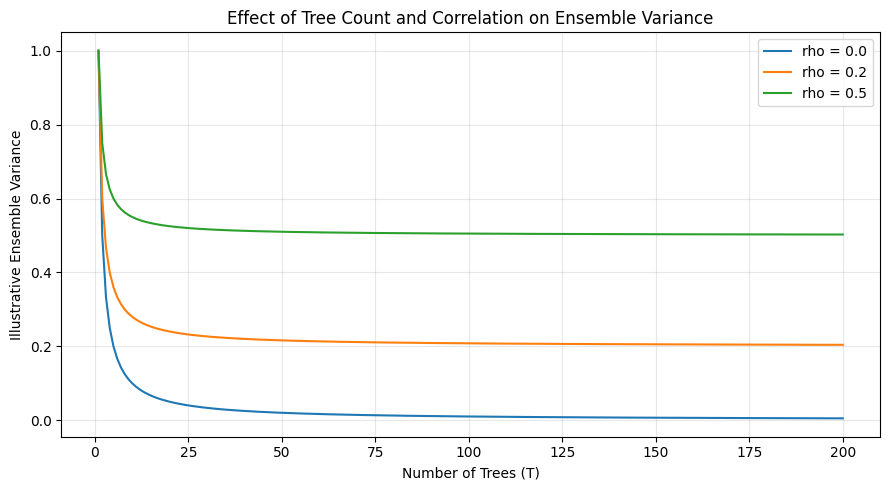

In [9]:
# Visualize how the theoretical variance changes with tree count
# under several illustrative tree-correlation values.
tree_counts_math = np.arange(1, 201)

sigma_squared = 1.0
correlations = [0.0, 0.2, 0.5]

plt.figure(figsize=(9, 5))

for rho in correlations:
    variance = sigma_squared * (
        rho + (1 - rho) / tree_counts_math
    )
    plt.plot(
        tree_counts_math,
        variance,
        label=f"rho = {rho}"
    )

plt.xlabel("Number of Trees (T)")
plt.ylabel("Illustrative Ensemble Variance")
plt.title("Effect of Tree Count and Correlation on Ensemble Variance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 6.5.8 Random Feature Selection

At a split, suppose the full feature set contains `p` predictors and the algorithm considers `m` of them:

$$
m < p
$$

The value of `m` is controlled by `max_features` in scikit-learn.

This mechanism has a statistical purpose: it encourages trees to make different decisions and therefore can reduce correlation among trees.

The forest is therefore balancing two ideas:

$$
\boxed{
\text{Strong individual trees}
+
\text{Diversity between trees}
\rightarrow
\text{Strong ensemble}
}
$$


## 7. A Small Random Forest From Scratch

This section is an **educational implementation**, not a production replacement for scikit-learn.

The goal is to make the mechanics visible:

1. Draw bootstrap samples.
2. Train a small decision tree on each sample.
3. Store the trees.
4. Collect their predictions.
5. Combine predictions using majority voting.

The implementation intentionally uses a simple and readable design rather than reproducing every optimization used by mature machine-learning libraries.


In [10]:
# Build a small educational Random Forest using scikit-learn trees.
from sklearn.tree import DecisionTreeClassifier

def bootstrap_sample(X, y, rng):
    # Draw n observations with replacement.
    n_samples = len(X)
    indices = rng.choice(n_samples, size=n_samples, replace=True)

    # Return the sampled rows and their labels.
    return X.iloc[indices], y.iloc[indices]


def train_educational_forest(X, y, n_trees=5, max_depth=3, random_state=42):
    # Create a reproducible random-number generator.
    rng = np.random.default_rng(random_state)

    trees = []

    for tree_number in range(n_trees):
        # Generate a different bootstrap sample for this tree.
        X_boot, y_boot = bootstrap_sample(X, y, rng)

        # Train a small decision tree on the bootstrap sample.
        tree = DecisionTreeClassifier(
            max_depth=max_depth,
            random_state=random_state + tree_number
        )
        tree.fit(X_boot, y_boot)

        # Store the fitted tree.
        trees.append(tree)

    return trees


def forest_predict(trees, X):
    # Collect predictions from every tree.
    predictions = np.column_stack([
        tree.predict(X) for tree in trees
    ])

    # Select the majority vote for each observation.
    final_predictions = []

    for row in predictions:
        values, counts = np.unique(row, return_counts=True)
        final_predictions.append(values[np.argmax(counts)])

    return np.array(final_predictions)


## 7.5 Visualizing a Random Forest

A Random Forest is not naturally represented by a single tree diagram because it contains many trees.

For teaching, however, it is useful to visualize several component trees side by side.

We will use **Matplotlib** to draw the first few trees from our educational forest. This makes the ensemble structure concrete:

```text
Tree 1       Tree 2       Tree 3       Tree 4
  /\          /\           /\           /\
 /  \        /  \         /  \         /  \
... ...      ... ...       ... ...       ... ...
       \        |             |             /
              voting
                 ↓
          forest prediction
```

The trees below are deliberately small so that their structure remains readable.


DATASET INFORMATION
Feature matrix shape: (569, 30)
Target names: ['malignant' 'benign']

Class distribution:
target
1    357
0    212
Name: count, dtype: int64

First five rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



TRAIN / TEST SPLIT
Training samples: 455
Testing samples : 114

TRAINING EDUCATIONAL RANDOM FOREST
Educational Random Forest created with 7 trees.
Educational Forest Test Accuracy: 0.9474

VISUALIZING COMPONENT TREES


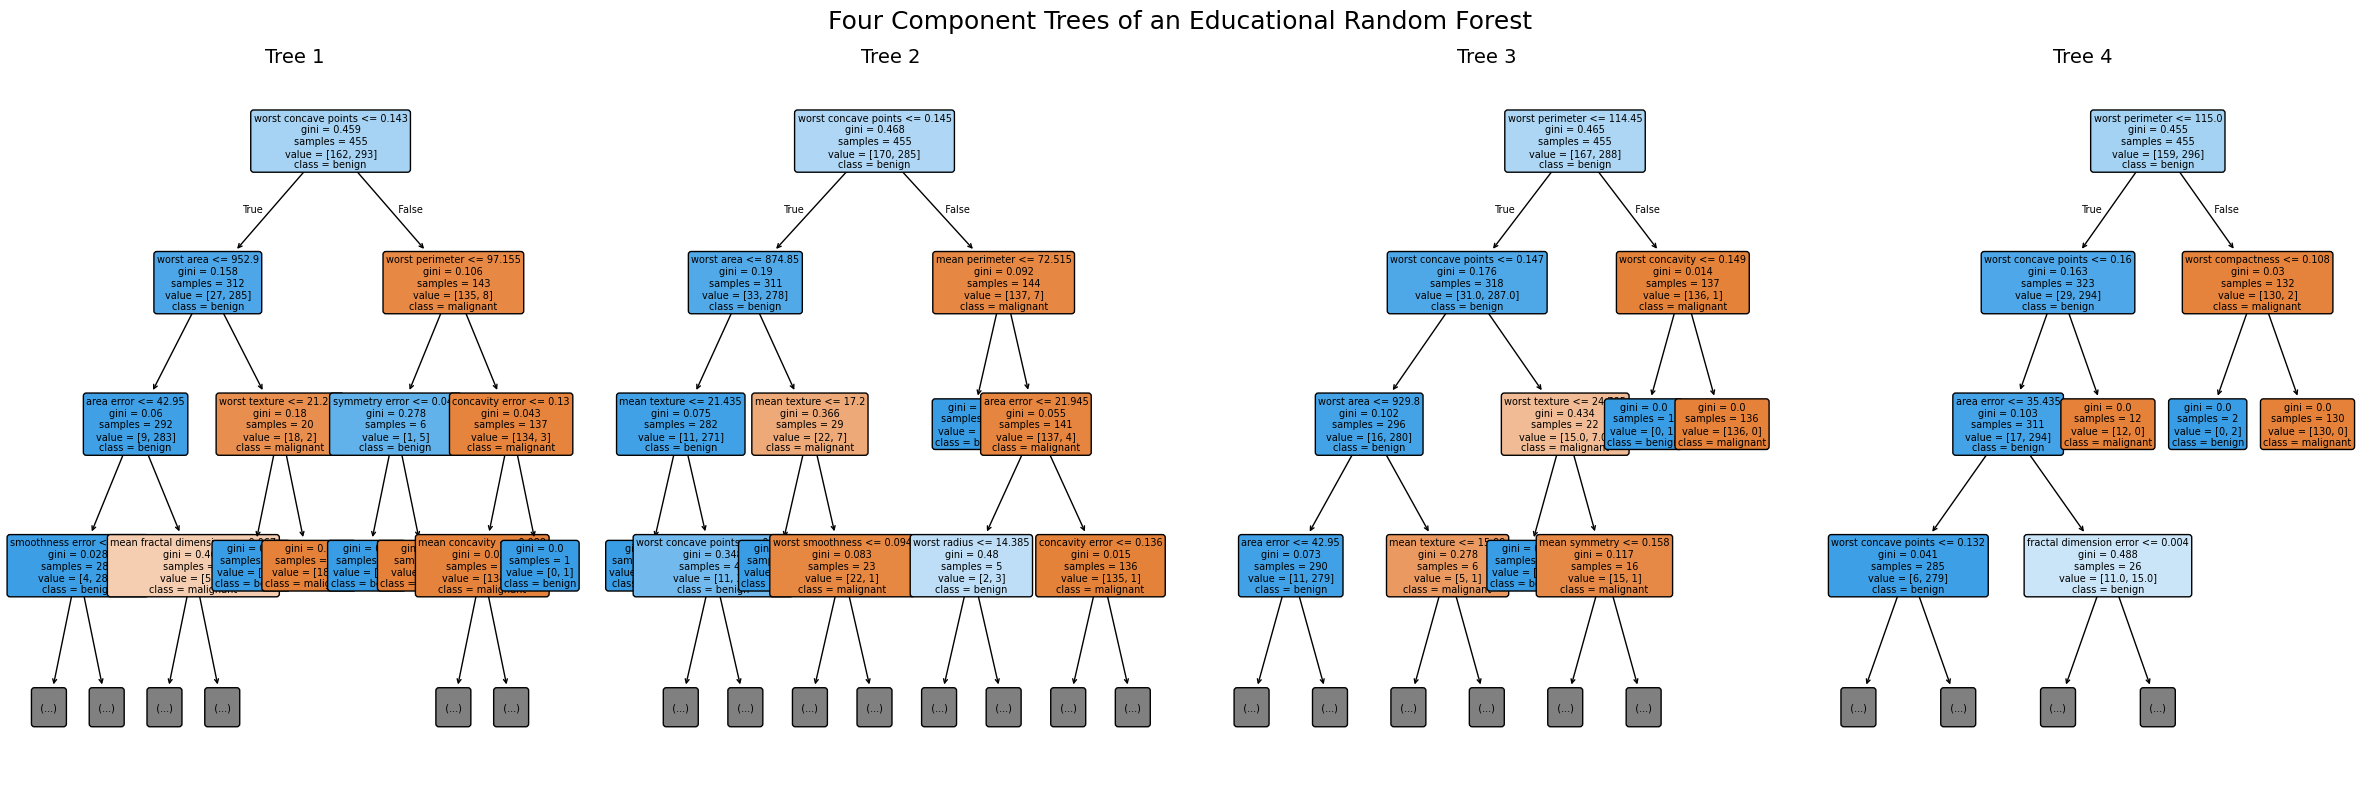

In [12]:
# ============================================================
# RANDOM FOREST — EDUCATIONAL IMPLEMENTATION + VISUALIZATION
# ============================================================
#
# This cell:
# 1. Imports the required libraries.
# 2. Loads the Breast Cancer dataset.
# 3. Splits the dataset into training and testing sets.
# 4. Creates bootstrap samples.
# 5. Builds an educational Random Forest.
# 6. Generates predictions using majority voting.
# 7. Visualizes four component trees using Matplotlib.
#
# You can run this entire cell independently.
# ============================================================


# ------------------------------------------------------------
# 1. Import required libraries
# ------------------------------------------------------------

# NumPy is used for numerical operations.
import numpy as np

# Pandas is used for working with tabular data.
import pandas as pd

# Matplotlib is used for visualization.
import matplotlib.pyplot as plt

# Load the breast cancer dataset from scikit-learn.
from sklearn.datasets import load_breast_cancer

# Split the dataset into training and testing sets.
from sklearn.model_selection import train_test_split

# DecisionTreeClassifier will be used as the base learner
# inside our educational Random Forest.
from sklearn.tree import DecisionTreeClassifier

# plot_tree is used to visualize individual decision trees.
from sklearn.tree import plot_tree


# ------------------------------------------------------------
# 2. Set the random state
# ------------------------------------------------------------

# A fixed random seed makes our experiment reproducible.
RANDOM_STATE = 42


# ------------------------------------------------------------
# 3. Load the Breast Cancer dataset
# ------------------------------------------------------------

# Load the built-in Wisconsin Diagnostic Breast Cancer dataset.
cancer = load_breast_cancer()


# ------------------------------------------------------------
# 4. Create the feature matrix X
# ------------------------------------------------------------

# Convert the NumPy feature matrix into a Pandas DataFrame.
# Each column represents one biological feature.
X = pd.DataFrame(
    cancer.data,
    columns=cancer.feature_names
)


# ------------------------------------------------------------
# 5. Create the target vector y
# ------------------------------------------------------------

# Convert the target array into a Pandas Series.
y = pd.Series(
    cancer.target,
    name="target"
)


# ------------------------------------------------------------
# 6. Display basic dataset information
# ------------------------------------------------------------

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

# Print the number of samples and features.
print("Feature matrix shape:", X.shape)

# Print the names of the target classes.
print("Target names:", cancer.target_names)

# Print the class distribution.
print("\nClass distribution:")
print(y.value_counts())

# Display the first five rows.
print("\nFirst five rows:")
display(X.head())


# ------------------------------------------------------------
# 7. Train/Test Split
# ------------------------------------------------------------

# Split the dataset into training and testing subsets.
#
# test_size=0.20:
#   20% of the data will be used for testing.
#
# random_state:
#   Makes the split reproducible.
#
# stratify=y:
#   Preserves approximately the same class proportions
#   in the training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)


# ------------------------------------------------------------
# 8. Display split information
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))


# ------------------------------------------------------------
# 9. Define Bootstrap Sampling
# ------------------------------------------------------------

def bootstrap_sample(X_data, y_data, rng):
    """
    Create one bootstrap sample.

    Bootstrap sampling means:
    - We randomly select observations.
    - Sampling is performed WITH replacement.
    - The bootstrap sample has the same number of observations
      as the original dataset.

    Parameters
    ----------
    X_data : pandas.DataFrame
        Feature matrix.

    y_data : pandas.Series
        Target vector.

    rng : NumPy random generator
        Random number generator.

    Returns
    -------
    X_boot : pandas.DataFrame
        Bootstrap feature matrix.

    y_boot : pandas.Series
        Bootstrap target vector.
    """

    # Get the number of observations.
    n_samples = len(X_data)

    # Randomly select row indices WITH replacement.
    indices = rng.choice(
        n_samples,
        size=n_samples,
        replace=True
    )

    # Select the corresponding feature rows.
    X_boot = X_data.iloc[indices]

    # Select the corresponding target values.
    y_boot = y_data.iloc[indices]

    # Return the bootstrap sample.
    return X_boot, y_boot


# ------------------------------------------------------------
# 10. Define the Educational Random Forest
# ------------------------------------------------------------

def train_educational_forest(
    X_data,
    y_data,
    n_trees=7,
    max_depth=4,
    random_state=42
):
    """
    Train a simple educational Random Forest.

    The algorithm performs the following steps:

    1. Create a bootstrap sample.
    2. Train a Decision Tree on that sample.
    3. Repeat the process for multiple trees.
    4. Store all trained trees.

    Note:
    This is an educational implementation.
    It demonstrates the bootstrap/ensemble idea clearly,
    but it is not intended to replace scikit-learn's optimized
    RandomForestClassifier.
    """

    # Create a reproducible random number generator.
    rng = np.random.default_rng(random_state)

    # Create an empty list for storing the trained trees.
    trees = []

    # Train the requested number of trees.
    for tree_number in range(n_trees):

        # ----------------------------------------------------
        # Create a bootstrap sample for this tree.
        # ----------------------------------------------------
        X_boot, y_boot = bootstrap_sample(
            X_data,
            y_data,
            rng
        )

        # ----------------------------------------------------
        # Create a Decision Tree.
        # ----------------------------------------------------
        tree = DecisionTreeClassifier(
            max_depth=max_depth,

            # Give every tree a slightly different seed.
            random_state=random_state + tree_number
        )

        # ----------------------------------------------------
        # Train the tree on its bootstrap sample.
        # ----------------------------------------------------
        tree.fit(
            X_boot,
            y_boot
        )

        # ----------------------------------------------------
        # Store the trained tree.
        # ----------------------------------------------------
        trees.append(tree)

    # Return the complete collection of trees.
    return trees


# ------------------------------------------------------------
# 11. Define Forest Prediction
# ------------------------------------------------------------

def forest_predict(trees, X_data):
    """
    Generate predictions using majority voting.

    Every tree produces one prediction.

    Example:

        Tree 1 -> 0
        Tree 2 -> 1
        Tree 3 -> 1
        Tree 4 -> 1
        Tree 5 -> 0

    Final prediction -> 1

    because class 1 received the majority of votes.
    """

    # Collect predictions from every tree.
    #
    # Each tree produces one column of predictions.
    predictions = np.column_stack([
        tree.predict(X_data)
        for tree in trees
    ])

    # Store the final majority-vote predictions.
    final_predictions = []

    # Process one observation at a time.
    for row in predictions:

        # Find unique classes and their vote counts.
        values, counts = np.unique(
            row,
            return_counts=True
        )

        # Select the class with the largest number of votes.
        majority_class = values[
            np.argmax(counts)
        ]

        # Store the majority vote.
        final_predictions.append(
            majority_class
        )

    # Convert the final predictions to NumPy format.
    return np.array(final_predictions)


# ------------------------------------------------------------
# 12. Train the Educational Random Forest
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TRAINING EDUCATIONAL RANDOM FOREST")
print("=" * 60)

# Number of trees in our educational forest.
N_TREES = 7

# Maximum depth of each educational tree.
MAX_DEPTH = 4

# Train the forest.
educational_trees = train_educational_forest(
    X_train,
    y_train,
    n_trees=N_TREES,
    max_depth=MAX_DEPTH,
    random_state=RANDOM_STATE
)

# Confirm that the forest was successfully created.
print(
    f"Educational Random Forest created with "
    f"{len(educational_trees)} trees."
)


# ------------------------------------------------------------
# 13. Generate predictions
# ------------------------------------------------------------

# Use all trees to predict the test set.
educational_predictions = forest_predict(
    educational_trees,
    X_test
)


# ------------------------------------------------------------
# 14. Calculate educational forest accuracy
# ------------------------------------------------------------

# Compare predictions with the true labels.
educational_accuracy = np.mean(
    educational_predictions == y_test.to_numpy()
)

print(
    f"Educational Forest Test Accuracy: "
    f"{educational_accuracy:.4f}"
)


# ------------------------------------------------------------
# 15. Visualize the first four trees
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("VISUALIZING COMPONENT TREES")
print("=" * 60)

# Create a figure containing four separate panels.
fig, axes = plt.subplots(
    1,
    4,
    figsize=(24, 8)
)


# ------------------------------------------------------------
# 16. Draw four trees
# ------------------------------------------------------------

# Select the first four trees.
for i, (ax, tree) in enumerate(
    zip(
        axes,
        educational_trees[:4]
    ),
    start=1
):

    # Draw the decision tree inside the current subplot.
    plot_tree(
        tree,

        # Draw this tree inside the current axis.
        ax=ax,

        # Display the actual feature names.
        feature_names=X_train.columns,

        # Display the class names.
        class_names=[
            str(name)
            for name in cancer.target_names
        ],

        # Color nodes according to their predicted class.
        filled=True,

        # Use rounded boxes for readability.
        rounded=True,

        # Limit the displayed depth so the figure remains readable.
        max_depth=3,

        # Use a small font because there are many feature names.
        fontsize=7
    )

    # Add a title above each individual tree.
    ax.set_title(
        f"Tree {i}",
        fontsize=14
    )


# ------------------------------------------------------------
# 17. Add the main figure title
# ------------------------------------------------------------

plt.suptitle(
    "Four Component Trees of an Educational Random Forest",
    fontsize=18
)


# ------------------------------------------------------------
# 18. Adjust the layout
# ------------------------------------------------------------

# Prevent the subplots and title from overlapping.
plt.tight_layout()


# ------------------------------------------------------------
# 19. Display the figure
# ------------------------------------------------------------

plt.show()


# ============================================================
# END OF CELL
# ============================================================
#
# At this point we have:
#
# educational_trees
#     ├── Tree 1
#     ├── Tree 2
#     ├── Tree 3
#     ├── Tree 4
#     ├── Tree 5
#     ├── Tree 6
#     └── Tree 7
#
# Each tree was trained on a different bootstrap sample.
#
# Their predictions are combined using majority voting.
# ============================================================

## 7.6 Visualizing Random Forest with `mglearn`

`mglearn` is a teaching-oriented visualization package commonly used with *Introduction to Machine Learning with Python*.

It is useful for showing the intuition behind machine-learning algorithms.

If `mglearn` is installed, the following section demonstrates how it can be used alongside scikit-learn. Because `mglearn` is an educational visualization helper rather than part of scikit-learn itself, the notebook also provides a fallback message if it is not installed.

> The goal here is conceptual visualization. The actual Random Forest model remains the scikit-learn estimator used elsewhere in this notebook.


In [13]:
# Try to import mglearn for educational visualizations.
try:
    import mglearn

    print("mglearn is installed.")
    print("Version:", getattr(mglearn, "__version__", "version not exposed"))
except ImportError:
    mglearn = None

    print(
        "mglearn is not installed in this environment. "
        "Install it with: pip install mglearn"
    )


mglearn is installed.
Version: 0.1.9


mglearn imported successfully.
Random Forest training accuracy: 0.930


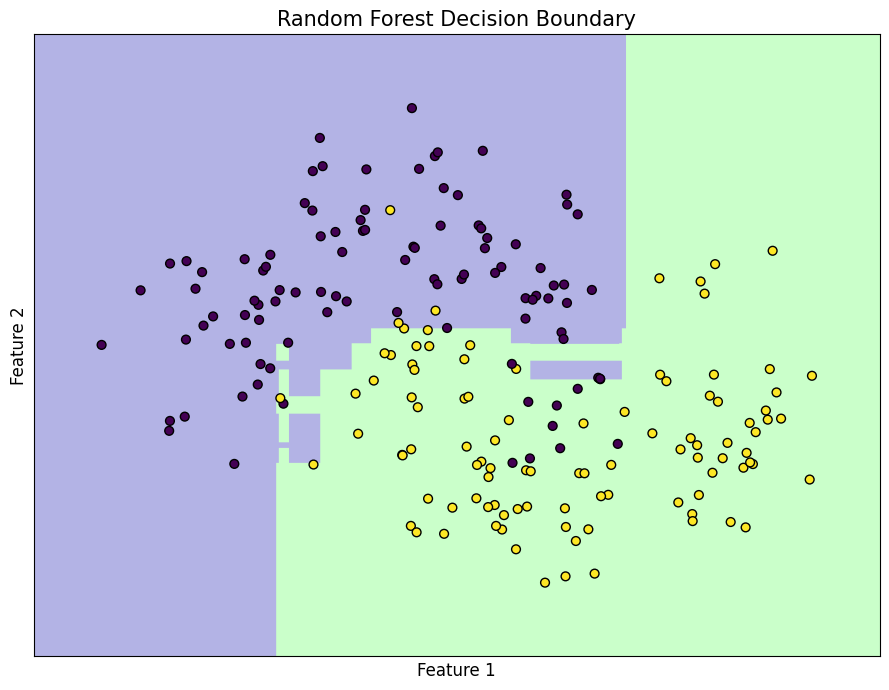

In [15]:
# ============================================================
# RANDOM FOREST DECISION BOUNDARY WITH MGLEARN
# ============================================================

# ------------------------------------------------------------
# 1. Import required libraries
# ------------------------------------------------------------

# NumPy is used for numerical operations.
import numpy as np

# Matplotlib is used for visualization.
import matplotlib.pyplot as plt

# Create a synthetic two-feature classification dataset.
from sklearn.datasets import make_moons

# Import the Random Forest classification algorithm.
from sklearn.ensemble import RandomForestClassifier


# ------------------------------------------------------------
# 2. Set random state
# ------------------------------------------------------------

# A fixed random seed makes the experiment reproducible.
RANDOM_STATE = 42


# ------------------------------------------------------------
# 3. Try to import mglearn
# ------------------------------------------------------------

# mglearn is an educational visualization library.
try:
    import mglearn

    print("mglearn imported successfully.")

except ImportError:

    # If mglearn is not installed, store None.
    mglearn = None

    print("mglearn is not installed.")
    print("Install it with:")
    print("pip install mglearn")


# ------------------------------------------------------------
# 4. Create a two-feature classification dataset
# ------------------------------------------------------------

# make_moons creates a nonlinear two-class dataset.
#
# n_samples:
#     Number of observations.
#
# noise:
#     Adds some random noise to make the problem more realistic.
#
# random_state:
#     Makes the generated dataset reproducible.
X_moons, y_moons = make_moons(
    n_samples=200,
    noise=0.25,
    random_state=RANDOM_STATE
)


# ------------------------------------------------------------
# 5. Create the Random Forest model
# ------------------------------------------------------------

# Create a small Random Forest.
#
# n_estimators=5:
#     Use five decision trees.
#
# max_depth=4:
#     Limit each tree to a maximum depth of four.
#
# random_state:
#     Makes the model reproducible.
rf_moons = RandomForestClassifier(
    n_estimators=5,
    max_depth=4,
    random_state=RANDOM_STATE
)


# ------------------------------------------------------------
# 6. Train the Random Forest
# ------------------------------------------------------------

# Fit the Random Forest on the synthetic dataset.
rf_moons.fit(
    X_moons,
    y_moons
)


# ------------------------------------------------------------
# 7. Calculate training accuracy
# ------------------------------------------------------------

# Calculate how accurately the forest classifies
# the training observations.
training_accuracy = rf_moons.score(
    X_moons,
    y_moons
)

print(
    f"Random Forest training accuracy: "
    f"{training_accuracy:.3f}"
)


# ------------------------------------------------------------
# 8. Visualize the decision boundary
# ------------------------------------------------------------

if mglearn is not None:

    # Create the figure.
    plt.figure(
        figsize=(9, 7)
    )

    # Let mglearn draw the classification regions.
    mglearn.plots.plot_2d_classification(
        rf_moons,
        X_moons,
        fill=True,
        alpha=0.3
    )

    # Draw the original observations on top
    # of the decision regions.
    plt.scatter(
        X_moons[:, 0],
        X_moons[:, 1],
        c=y_moons,
        edgecolor="black",
        s=40
    )

    # Label the first feature.
    plt.xlabel(
        "Feature 1",
        fontsize=12
    )

    # Label the second feature.
    plt.ylabel(
        "Feature 2",
        fontsize=12
    )

    # Add the figure title.
    plt.title(
        "Random Forest Decision Boundary",
        fontsize=15
    )

    # Add a grid to make the decision regions easier to inspect.
    plt.grid(
        True,
        alpha=0.25
    )

    # Adjust the layout.
    plt.tight_layout()

    # Display the figure.
    plt.show()

else:

    # Inform the user that mglearn must be installed.
    print(
        "The Random Forest was trained successfully, "
        "but mglearn is not installed."
    )

    print(
        "Run this command in a notebook cell:"
    )

    print(
        "!pip install mglearn"
    )

### What should this visualization teach?

The decision boundary is made by combining many tree-based rules.

A single tree can create a highly fragmented, axis-aligned decision surface. A forest combines many such trees, which can produce a more stable boundary.

The exact appearance depends on:

- the number of trees,
- tree depth,
- bootstrap samples,
- feature selection,
- and the random seed.

The visualization is therefore a teaching tool rather than a mathematical proof of model quality.


## 8. Load a Real Dataset

We use scikit-learn's **Wisconsin Diagnostic Breast Cancer** dataset.

The dataset contains 569 observations and 30 numeric features.

The target names are:

- `malignant`
- `benign`

This dataset is used here for educational machine-learning practice. It must not be interpreted as a clinical diagnostic system.


In [16]:
# Load the built-in breast cancer dataset.
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

# Convert the feature matrix into a DataFrame.
X = pd.DataFrame(
    cancer.data,
    columns=cancer.feature_names
)

# Store the target as a Series.
y = pd.Series(
    cancer.target,
    name="target"
)

# Display basic dataset information.
print("Feature matrix shape:", X.shape)
print("Target names:", cancer.target_names)

display(X.head())

print("\nClass distribution:")
print(
    y.value_counts()
     .rename(index={0: "malignant", 1: "benign"})
)


Feature matrix shape: (569, 30)
Target names: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Class distribution:
target
benign       357
malignant    212
Name: count, dtype: int64


## 9. Train / Test Split

The data must be split before the final model is evaluated.

- **Training set:** used to fit models.
- **Test set:** held out for a final performance estimate.

We use `stratify=y` so that the class proportions are approximately preserved between the training and test sets.

The test set should not be repeatedly used as a tuning target.


In [17]:
# Split the dataset before fitting the final model.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

print("\nTraining class proportions:")
print(y_train.value_counts(normalize=True).sort_index())


Training samples: 455
Test samples: 114

Training class proportions:
target
0    0.373626
1    0.626374
Name: proportion, dtype: float64


## 10. Train a Small Educational Forest

Before using a large production-style forest, let's verify that our small educational implementation works.

This section is primarily about understanding the mechanics rather than maximizing performance.


In [18]:
# Train a small educational forest.
educational_trees = train_educational_forest(
    X_train,
    y_train,
    n_trees=7,
    max_depth=4,
    random_state=RANDOM_STATE
)

# Generate predictions from the ensemble.
educational_predictions = forest_predict(
    educational_trees,
    X_test
)

educational_accuracy = np.mean(
    educational_predictions == y_test.to_numpy()
)

print("Number of educational trees:", len(educational_trees))
print("Educational forest test accuracy:", educational_accuracy)


Number of educational trees: 7
Educational forest test accuracy: 0.9473684210526315


## 11. Train a Random Forest with Scikit-learn

For a real workflow, we use `RandomForestClassifier`.

Important parameters include:

- `n_estimators`: number of trees.
- `criterion`: split-quality criterion.
- `max_depth`: maximum depth of each tree.
- `min_samples_split`: minimum samples required to split a node.
- `min_samples_leaf`: minimum samples in a leaf.
- `max_features`: number of features considered at a split.
- `bootstrap`: whether bootstrap samples are used.
- `oob_score`: whether OOB evaluation is calculated.
- `class_weight`: optional class weighting.
- `random_state`: controls reproducibility where randomness is involved.


In [19]:
# Import and train the production-style Random Forest classifier.
from sklearn.ensemble import RandomForestClassifier

rf_baseline = RandomForestClassifier(
    n_estimators=200,
    criterion="gini",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Fit the forest only on training data.
rf_baseline.fit(X_train, y_train)

print("Training accuracy:", rf_baseline.score(X_train, y_train))
print("Test accuracy:", rf_baseline.score(X_test, y_test))
print("Number of trees:", len(rf_baseline.estimators_))


Training accuracy: 1.0
Test accuracy: 0.956140350877193
Number of trees: 200


## 12. Evaluate the Random Forest

Accuracy is useful, but it should not be the only metric.

For classification we examine:

- Confusion matrix
- Accuracy
- Precision
- Recall
- F1 score
- ROC-AUC

The appropriate metric depends on the problem and the relative cost of different errors.


In [20]:
# Calculate standard classification metrics.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Generate class predictions and probabilities.
y_pred = rf_baseline.predict(X_test)
y_proba = rf_baseline.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba))

print("\nClassification report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=cancer.target_names[::-1]
))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy : 0.956140350877193
Precision: 0.958904109589041
Recall   : 0.9722222222222222
F1 score : 0.9655172413793104
ROC-AUC  : 0.9930555555555556

Classification report:
              precision    recall  f1-score   support

      benign       0.95      0.93      0.94        42
   malignant       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Confusion matrix:
[[39  3]
 [ 2 70]]


## 13. Confusion Matrix Visualization

A confusion matrix separates predictions into categories such as:

- True positives
- True negatives
- False positives
- False negatives

Looking at these errors is often more informative than looking at a single accuracy value.


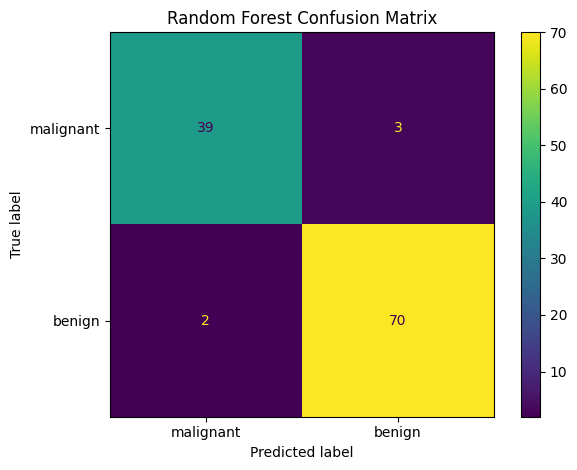

In [21]:
# Plot the confusion matrix without manually choosing a color style.
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=cancer.target_names
)

plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()


## 14. ROC Curve

The ROC curve examines the trade-off between:

- True Positive Rate
- False Positive Rate

across different classification thresholds.

The ROC-AUC summarizes the ranking performance across those thresholds.

It should still be interpreted in the context of the dataset and the application.


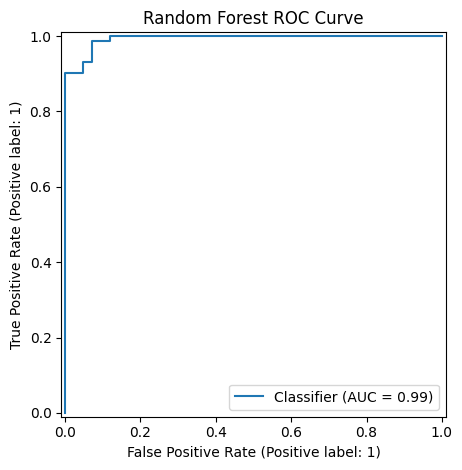

In [22]:
# Plot the ROC curve.
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_proba
)

plt.title("Random Forest ROC Curve")
plt.tight_layout()
plt.show()


## 15. Out-of-Bag (OOB) Evaluation

When bootstrap sampling is used, each tree leaves out some training observations.

Those observations are called **out-of-bag** for that tree.

Random Forest can use these OOB observations to produce an additional performance estimate without requiring a separate validation split for that particular estimate.

OOB evaluation is useful, but it does not remove the need for a properly held-out final test set.


In [23]:
# Train a forest with OOB evaluation enabled.
rf_oob = RandomForestClassifier(
    n_estimators=300,
    bootstrap=True,
    oob_score=True,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_oob.fit(X_train, y_train)

print("OOB score:", rf_oob.oob_score_)
print("Held-out test accuracy:", rf_oob.score(X_test, y_test))


OOB score: 0.9560439560439561
Held-out test accuracy: 0.9473684210526315


## 15.5 Visualizing Bootstrap Samples and OOB Observations

For teaching, we can visualize which observations were selected for several bootstrap samples.

A value of `1` means the observation appeared at least once in that tree's bootstrap sample. A value of `0` means it was OOB for that tree.

This makes the relationship between bootstrap sampling and OOB evaluation visible.


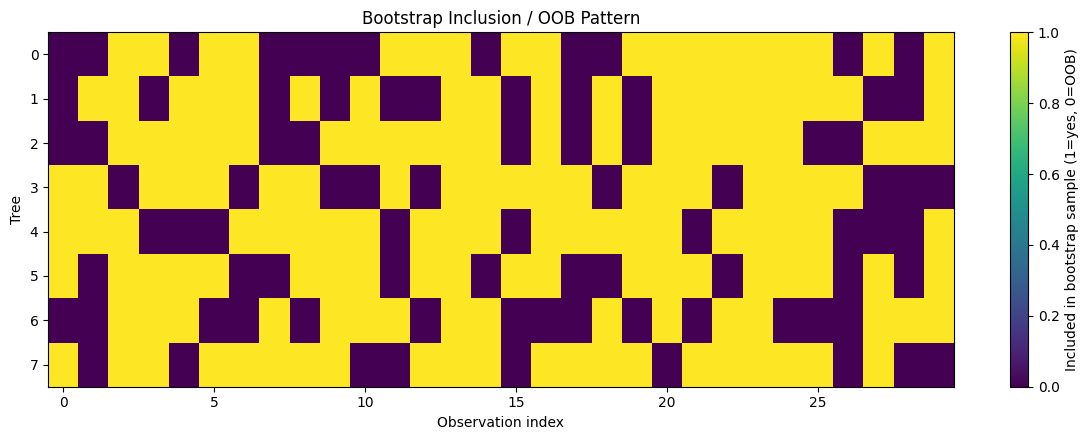

In [24]:
# Visualize bootstrap inclusion for several hypothetical trees.
rng = np.random.default_rng(RANDOM_STATE)

n_demo_observations = 30
n_demo_trees = 8

bootstrap_matrix = np.zeros(
    (n_demo_trees, n_demo_observations),
    dtype=int
)

for tree_idx in range(n_demo_trees):
    # Draw n observations with replacement.
    sampled = rng.choice(
        n_demo_observations,
        size=n_demo_observations,
        replace=True
    )

    # Mark observations that appeared at least once.
    bootstrap_matrix[
        tree_idx,
        np.unique(sampled)
    ] = 1

plt.figure(figsize=(12, 4.5))

plt.imshow(
    bootstrap_matrix,
    aspect="auto",
    interpolation="nearest"
)

plt.xlabel("Observation index")
plt.ylabel("Tree")
plt.title("Bootstrap Inclusion / OOB Pattern")
plt.colorbar(label="Included in bootstrap sample (1=yes, 0=OOB)")
plt.tight_layout()
plt.show()


## 16. How Many Trees Should We Use?

Increasing `n_estimators` gives the ensemble more trees.

More trees generally increase computation time. After a point, additional trees may provide diminishing returns.

We can examine this experimentally rather than assuming that a particular number is always optimal.


In [25]:
# Compare several numbers of trees.
tree_counts = [10, 25, 50, 100, 200, 400]
tree_results = []

for n_trees in tree_counts:
    # Train a forest with the selected number of trees.
    model = RandomForestClassifier(
        n_estimators=n_trees,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    # Record training and test accuracy.
    tree_results.append({
        "n_estimators": n_trees,
        "train_accuracy": model.score(X_train, y_train),
        "test_accuracy": model.score(X_test, y_test)
    })

tree_results_df = pd.DataFrame(tree_results)
display(tree_results_df)


,n_estimators,train_accuracy,test_accuracy
0,10,0.995604,0.938596
1,25,1.000000,0.956140
2,50,1.000000,0.956140
3,100,1.000000,0.956140
4,200,1.000000,0.956140
5,400,1.000000,0.956140


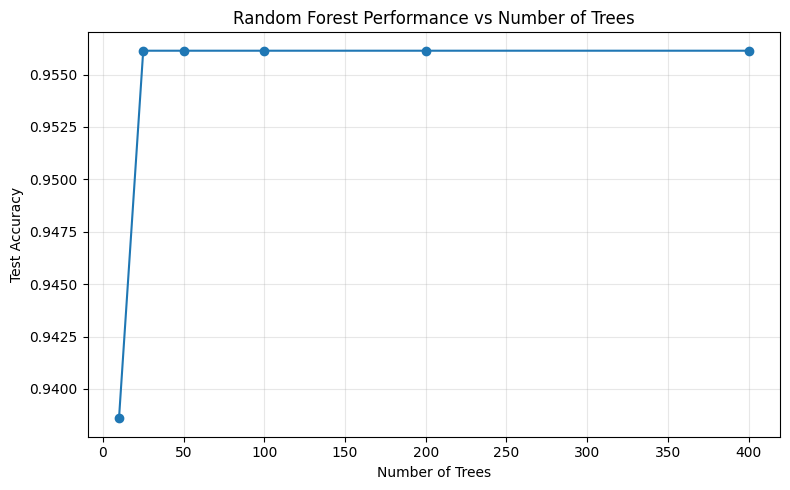

In [27]:
# Plot test accuracy as the number of trees changes.
plt.figure(figsize=(8, 5))

plt.plot(
    tree_results_df["n_estimators"],
    tree_results_df["test_accuracy"],
    marker="o"
)

plt.xlabel("Number of Trees")
plt.ylabel("Test Accuracy")
plt.title("Random Forest Performance vs Number of Trees")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 17. Feature Importance

Random Forest provides impurity-based feature importance through `feature_importances_`.

These values can be useful for exploratory interpretation, but they should not automatically be interpreted as causal effects or proof that a feature is biologically important.

Correlated features can also complicate interpretation.


In [28]:
# Extract impurity-based feature importance.
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_baseline.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

display(feature_importance.head(15))


,feature,importance
22,worst perimeter,0.133100
23,worst area,0.128052
27,worst concave points,0.108107
7,mean concave points,0.094414
20,worst radius,0.090639
0,mean radius,0.058662
2,mean perimeter,0.055242
3,mean area,0.049938
6,mean concavity,0.046207
26,worst concavity,0.035357


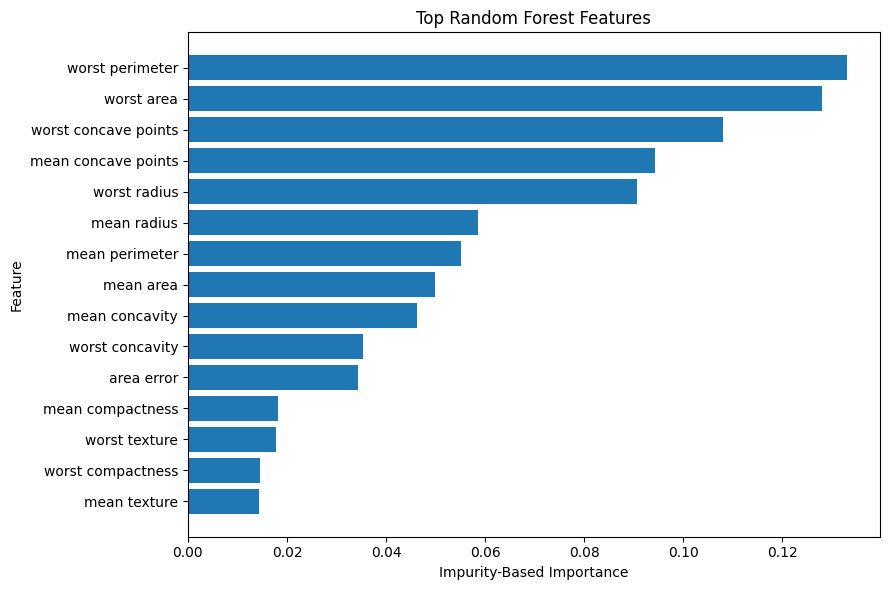

In [29]:
# Visualize the most important features.
top_features = feature_importance.head(15).sort_values("importance")

plt.figure(figsize=(9, 6))
plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Impurity-Based Importance")
plt.ylabel("Feature")
plt.title("Top Random Forest Features")
plt.tight_layout()
plt.show()


## 18. Permutation Importance

Permutation importance measures how much model performance changes when a feature's values are randomly permuted.

The intuition is:

> If shuffling a feature substantially reduces performance, the fitted model was relying on information contained in that feature.

Permutation importance is another interpretation tool and should be interpreted in the context of correlated predictors and the evaluation dataset.


In [30]:
# Calculate permutation importance on the held-out test set.
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    rf_baseline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="accuracy",
    n_jobs=-1
)

permutation_df = pd.DataFrame({
    "feature": X.columns,
    "mean_importance": perm_result.importances_mean,
    "std_importance": perm_result.importances_std
}).sort_values(
    "mean_importance",
    ascending=False
)

display(permutation_df.head(15))


,feature,mean_importance,std_importance
3,mean area,0.008772,0.000000
15,compactness error,0.008772,0.000000
22,worst perimeter,0.008772,0.007846
23,worst area,0.007895,0.008275
7,mean concave points,0.007895,0.007287
0,mean radius,0.007018,0.003509
21,worst texture,0.007018,0.003509
20,worst radius,0.007018,0.005263
17,concave points error,0.006140,0.004020
27,worst concave points,0.005263,0.004297


## 19. Random Forest Hyperparameters

The most important hyperparameters to understand include:

### `n_estimators`
Number of trees in the forest.

### `max_depth`
Maximum depth of individual trees. Smaller values constrain tree complexity.

### `max_features`
Controls how many features are considered at each split.

### `min_samples_split`
Controls how many samples are needed before a node can be split.

### `min_samples_leaf`
Sets the minimum number of samples allowed in a leaf.

### `bootstrap`
Controls whether bootstrap samples are used.

### `class_weight`
Can be useful when classes have substantially different importance or frequencies.

There is no universally best setting. Hyperparameters should be selected using an appropriate validation strategy rather than by repeatedly optimizing on the final test set.


## 20. Cross-Validation and Hyperparameter Tuning

We now use cross-validation on the training data to compare a small, controlled set of configurations.

The held-out test set remains untouched until final evaluation.


In [31]:
# Tune a compact set of Random Forest hyperparameters.
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "max_features": ["sqrt", "log2"],
    "min_samples_leaf": [1, 2]
}

rf_for_search = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=rf_for_search,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest mean cross-validation score:")
print(grid_search.best_score_)


Best parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}

Best mean cross-validation score:
0.9604395604395606


In [32]:
# Inspect the strongest configurations found by cross-validation.
cv_results = pd.DataFrame(grid_search.cv_results_)

summary_columns = [
    "params",
    "mean_train_score",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]

display(
    cv_results[summary_columns]
    .sort_values("rank_test_score")
    .head(10)
)


,params,mean_train_score,mean_test_score,std_test_score,rank_test_score
1,"{'max_depth': None, 'max_features': 'sqrt', 'm...",1.000000,0.960440,0.019160,1
17,"{'max_depth': 10, 'max_features': 'sqrt', 'min...",1.000000,0.960440,0.019160,1
11,"{'max_depth': 5, 'max_features': 'sqrt', 'min_...",0.992857,0.958242,0.022413,3
6,"{'max_depth': None, 'max_features': 'log2', 'm...",0.992857,0.958242,0.014579,4
23,"{'max_depth': 10, 'max_features': 'log2', 'min...",0.992857,0.958242,0.016150,4
22,"{'max_depth': 10, 'max_features': 'log2', 'min...",0.992857,0.958242,0.014579,4
7,"{'max_depth': None, 'max_features': 'log2', 'm...",0.992857,0.958242,0.016150,4
2,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.992308,0.956044,0.025059,8
18,"{'max_depth': 10, 'max_features': 'sqrt', 'min...",0.992308,0.956044,0.025059,8
5,"{'max_depth': None, 'max_features': 'log2', 'm...",1.000000,0.956044,0.015541,10


## 21. Final Tuned Model Evaluation

The best configuration selected by cross-validation is now evaluated once on the held-out test set.

This keeps the roles of training data, model selection, and final evaluation separate.


In [33]:
# Retrieve the best model selected by cross-validation.
best_rf = grid_search.best_estimator_

# Evaluate the tuned model on the held-out test set.
best_pred = best_rf.predict(X_test)
best_proba = best_rf.predict_proba(X_test)[:, 1]

final_metrics = {
    "accuracy": accuracy_score(y_test, best_pred),
    "precision": precision_score(y_test, best_pred),
    "recall": recall_score(y_test, best_pred),
    "f1": f1_score(y_test, best_pred),
    "roc_auc": roc_auc_score(y_test, best_proba)
}

display(pd.DataFrame(
    [final_metrics]
))


,accuracy,precision,recall,f1,roc_auc
0,0.95614,0.958904,0.972222,0.965517,0.993056


## 22. Random Forest vs Decision Tree

A direct comparison helps make the motivation for ensemble learning concrete.

We train a Decision Tree using the same training/test split and compare it with the tuned Random Forest.


In [34]:
# Train a baseline Decision Tree for direct comparison.
decision_tree = DecisionTreeClassifier(
    random_state=RANDOM_STATE
)

decision_tree.fit(X_train, y_train)

# Collect comparable metrics for both models.
comparison = pd.DataFrame([
    {
        "model": "Decision Tree",
        "train_accuracy": decision_tree.score(X_train, y_train),
        "test_accuracy": accuracy_score(
            y_test,
            decision_tree.predict(X_test)
        )
    },
    {
        "model": "Random Forest",
        "train_accuracy": best_rf.score(X_train, y_train),
        "test_accuracy": accuracy_score(
            y_test,
            best_pred
        )
    }
])

display(comparison)


,model,train_accuracy,test_accuracy
0,Decision Tree,1.0,0.912281
1,Random Forest,1.0,0.956140


## 23. Interpreting the Comparison

A Random Forest often produces a more stable generalization performance than a single unrestricted decision tree because it averages over many trees.

However, the exact difference depends on:

- Dataset size and structure
- Feature relationships
- Hyperparameters
- Noise
- Class balance
- Evaluation strategy

The experiment above should therefore be interpreted as an empirical result for this dataset and split, not as a universal guarantee.


## 24. Feature Scaling

Tree-based models generally do not require the same kind of feature scaling used by algorithms that depend directly on distances or gradient geometry.

For Random Forest, changing a feature from one linear unit scale to another generally does not change the ordering of values used by threshold-based splits.

This does not mean preprocessing is irrelevant. Missing values, categorical variables, leakage, and inconsistent data preparation still require careful handling.


## 25. Class Imbalance

Accuracy can be misleading when classes are highly imbalanced.

For example, if 95% of observations belong to one class, a classifier that always predicts that majority class can achieve 95% accuracy while being useless for detecting the minority class.

For imbalanced classification, inspect metrics such as:

- Precision
- Recall
- F1
- ROC-AUC
- Precision-Recall behavior
- Confusion matrix

Random Forest also supports options such as `class_weight` that can be considered as part of a carefully validated workflow.


In [35]:
# Show the class distribution in the training data.
class_distribution = (
    y_train
    .value_counts()
    .rename(index={0: "malignant", 1: "benign"})
    .rename("count")
    .to_frame()
)

class_distribution["proportion"] = (
    class_distribution["count"] /
    class_distribution["count"].sum()
)

display(class_distribution)


,count,proportion
target,,
benign,285,0.626374
malignant,170,0.373626


## 26. Common Failure Modes

### 1. Data leakage
Information from the test set or future data accidentally influences training.

### 2. Test-set tuning
Repeatedly changing the model after looking at test performance turns the test set into a tuning resource.

### 3. Reporting only accuracy
Accuracy can hide important error patterns.

### 4. Treating feature importance as causality
Importance measures describe model behavior, not causal relationships.

### 5. Ignoring correlated features
Correlated predictors can distribute or distort importance.

### 6. Assuming more trees always means a better model
Additional trees increase computation and can show diminishing returns.

### 7. Ignoring class imbalance
A high accuracy can coexist with poor minority-class detection.

### 8. Overinterpreting one train/test split
A single split can be noisy. Cross-validation provides a more robust basis for model selection.


## 27. Reproducibility Checklist

For a reproducible Random Forest experiment, record:

- Dataset and its version/source
- Feature definitions
- Target definition
- Train/test split strategy
- Random seed
- Cross-validation strategy
- Hyperparameter search space
- Selected hyperparameters
- Evaluation metrics
- Software/library versions

Reproducibility is part of a trustworthy machine-learning workflow.


In [36]:
# Record the key library versions used in the notebook.
import sklearn
import sys

print("Python version:", sys.version.split()[0])
print("scikit-learn version:", sklearn.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)


Python version: 3.13.15
scikit-learn version: 1.9.0
NumPy version: 2.3.3
Pandas version: 2.3.3


## 28. Summary

Random Forest combines many decision trees through ensemble learning.

The key ideas are:

1. **Bootstrap sampling** creates different training sets.
2. **Random feature selection** creates additional diversity.
3. **Decision trees** learn nonlinear decision rules.
4. **Voting** combines tree predictions for classification.
5. **OOB observations** can provide an additional validation signal.
6. **Feature importance and permutation importance** can help with interpretation, but neither proves causality.
7. **Cross-validation** is useful for model selection.
8. **A held-out test set** should remain separate for final evaluation.

The main conceptual transition is:

```text
One tree
   ↓
Many diverse trees
   ↓
Ensemble
   ↓
More stable prediction
```


## Random Forest Mastery Checklist

Before moving on, you should be able to answer:

- What problem does Random Forest solve compared with a single Decision Tree?
- What is bootstrap sampling?
- What does "with replacement" mean?
- What are OOB observations?
- Why are features randomly sampled at splits?
- How does majority voting work?
- What does `n_estimators` control?
- What does `max_features` control?
- What does `max_depth` control?
- Why can Random Forest still overfit?
- How does OOB evaluation work?
- Why should the test set remain untouched during tuning?
- Why can feature importance be misleading?
- Why might permutation importance be useful?
- When can accuracy be a poor metric?
- How does Random Forest differ from a single Decision Tree?


## 29. Final Conceptual Picture

The Random Forest pipeline can now be summarized mathematically:

$$
D
\xrightarrow{\text{bootstrap}}
D_1,D_2,\ldots,D_T
$$

Each dataset produces a tree:

$$
D_t \rightarrow Tree_t
$$

At each split, only a random subset of features is considered.

For classification:

$$
\hat y =
\operatorname{mode}
\left(
Tree_1(x),Tree_2(x),\ldots,Tree_T(x)
\right)
$$

For regression:

$$
\hat y =
\frac{1}{T}
\sum_{t=1}^{T}Tree_t(x)
$$

And the ensemble benefit is closely related to both:

$$
\boxed{
\text{individual tree strength}
+
\text{tree diversity}
}
$$